## Imports/Load/Options

In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATASET_ZIP = "../dataset/dataset.zip"
CSV_NAME = "final.csv"

# Chuking config
SAMPLE_SIZE = 300_000
RANDOM_STATE = 42

## Full Dataset Details

In [2]:
with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        n_lines = 0
        columns = None
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000):
            if columns is None:
                columns = list(chunk.columns)
                c_types = chunk.dtypes
            n_lines += len(chunk)

print(f"Line Count: {n_lines:,}")
print()
print(c_types.to_string())

Line Count: 4,396,534

data_pesquisa            str
id_empresa           float64
rede                     str
codigo_categoria     float64
id_produto             int64
descricao                str
preco_regular        float64
preco_atacado        float64
preco_atacado_qtd      int64
preco_promocao       float64
preco_fidelidade     float64


## Sampling

In [3]:
samples = []

with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        chunks_read = 0
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000):
            chunks_read += 1
            frac = SAMPLE_SIZE / n_lines
            n_sample_chunk = max(1, int(len(chunk) * frac))
            samples.append(chunk.sample(n=n_sample_chunk, random_state=RANDOM_STATE))

df = pd.concat(samples, ignore_index=True)
print(f"Sample Size: {len(df):,} records ({chunks_read} chunks read)")

Sample Size: 299,993 records (9 chunks read)


## Cleanup

In [4]:
# Padronizing all non float to Int64 (nullable) and converting dates to datetime
df["data_pesquisa"] = pd.to_datetime(df["data_pesquisa"], errors="coerce").dt.normalize()
df["id_empresa"] = df["id_empresa"].astype("Int64")
df["codigo_categoria"] = df["codigo_categoria"].astype("Int64")
df["id_produto"] = df["id_produto"].astype("Int64")
df["preco_atacado_qtd"] = df["preco_atacado_qtd"].astype("Int64")

print(df.dtypes.to_string())
print()
df.head()

data_pesquisa        datetime64[us]
id_empresa                    Int64
rede                            str
codigo_categoria              Int64
id_produto                    Int64
descricao                       str
preco_regular               float64
preco_atacado               float64
preco_atacado_qtd             Int64
preco_promocao              float64
preco_fidelidade            float64



,data_pesquisa,id_empresa,rede,codigo_categoria,id_produto,descricao,preco_regular,preco_atacado,preco_atacado_qtd,preco_promocao,preco_fidelidade
0,2026-08-07,115,Super muffato,6,7891024035047,Sabonete antibacteriano -protex -85 gr,3.74,0.0,0,0.0,0.0
1,2026-07-06,75,Jacomar,1,7898342050257,Sardinha molho de tomate -nautique -125 gr,5.29,0.0,0,0.0,0.0
2,2026-07-27,<NA>,Max atacadista,1,7897001010304,Oleo de canola -suavit -900 ml,11.19,0.0,0,0.0,0.0
3,2026-07-29,104,Festval,1,7898171400049,Feijao preto -pe vermelho -1 kg,5.98,0.0,0,0.0,0.0
4,2026-04-14,80,Super boni,<NA>,7896181710240,Mandolate -dacolonia -130 gr,7.49,0.0,0,0.0,0.0


## Null count

In [5]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)

null_table = pd.DataFrame({"null_count": nulls, "null_pct": null_pct})
null_table = null_table[null_table["null_count"] > 0].sort_values("null_count", ascending=False)
print(null_table)

                  null_count  null_pct
id_empresa             33598      11.2
codigo_categoria        5102       1.7


## Stats

In [6]:
price_columns = ["preco_regular", "preco_atacado", "preco_promocao", "preco_fidelidade"]

stats = df[price_columns].describe().T
stats["variancia"] = df[price_columns].var()
stats["coef variancia"] = (df[price_columns].std() / df[price_columns].mean()).round(3)
stats["moda"] = df[price_columns].mode().iloc[0]
stats["amplitude"] = df[price_columns].max() - df[price_columns].min()

stats

,count,mean,std,min,25%,50%,75%,max,variancia,coef variancia,moda,amplitude
preco_regular,299993.0,10.532545,10.847737,0.0,4.1,6.95,12.9,429.00,117.673405,1.030,4.99,429.00
preco_atacado,299993.0,0.062664,0.847613,0.0,0.0,0.00,0.0,55.90,0.718448,13.526,0.00,55.90
preco_promocao,299993.0,0.122069,1.354600,0.0,0.0,0.00,0.0,89.99,1.834941,11.097,0.00,89.99
preco_fidelidade,299993.0,0.027213,0.634673,0.0,0.0,0.00,0.0,45.90,0.402810,23.322,0.00,45.90


In [7]:
quantiles = df["preco_regular"].quantile([0.25, 0.5, 0.75])
decis = df["preco_regular"].quantile([i / 10 for i in range(1, 10)])
key_percentiles = df["preco_regular"].quantile([0.01, 0.05, 0.95, 0.99])

print("preco_regular quartis:")
print(quantiles.to_string())
print("\npreco_regular decis:")
print(decis.to_string())
print("\npreco_regular percentiles:")
print(key_percentiles.to_string())

preco_regular quartis:
0.25     4.10
0.50     6.95
0.75    12.90

preco_regular decis:
0.1     2.79
0.2     3.89
0.3     4.78
0.4     5.69
0.5     6.95
0.6     8.19
0.7    10.90
0.8    14.99
0.9    22.99

preco_regular percentiles:
0.01     0.000
0.05     1.990
0.95    31.954
0.99    54.900


## Outliers

In [8]:
q1 = df["preco_regular"].quantile(0.25)
q3 = df["preco_regular"].quantile(0.75)
iqr = q3 - q1
floor = q1 - 1.5 * iqr
ceiling = q3 + 1.5 * iqr

outliers = df[(df["preco_regular"] < floor) | (df["preco_regular"] > ceiling)]
print(f"Limite Inferior: {floor:.2f}")
print(f"Limite Superior: {ceiling:.2f}")
print(f"Outliers: {len(outliers):,} ({100*len(outliers)/len(df):.2f}% of sample)")
print()

invalid_prices = df[df["preco_regular"] <= 0]
print(f"Preços <= 0: {len(invalid_prices):,} ({100*len(invalid_prices)/len(df):.2f}%)")
print()

print("Top 10 preços")
print(df.nlargest(10, "preco_regular")[["descricao", "rede", "preco_regular"]].to_string(index=False))

Limite Inferior: -9.10
Limite Superior: 26.10
Outliers: 23,044 (7.68% of sample)

Preços <= 0: 4,682 (1.56%)

Top 10 preços
                                           descricao      rede  preco_regular
        Carne bovina posta vermelha s- osso (pedaco) Rio verde         429.00
                              Cerveja antartica lata       Big         212.19
                    Carne bovina file mignon s- osso  Angeloni         155.90
Carne bovina file mignon s/ osso -( + ) barato -1 kg   Festval         149.98
Carne bovina file mignon s/ osso -( + ) barato -1 kg   Festval         139.98
                    Carne bovina file mignon s- osso         G         139.75
                    Carne bovina file mignon s- osso       Big         135.00
                    Carne bovina file mignon s- osso  Festival         128.90
                    Carne bovina file mignon s- osso  Angeloni         127.90
                    Carne bovina file mignon s- osso         G         126.88


## Distribution

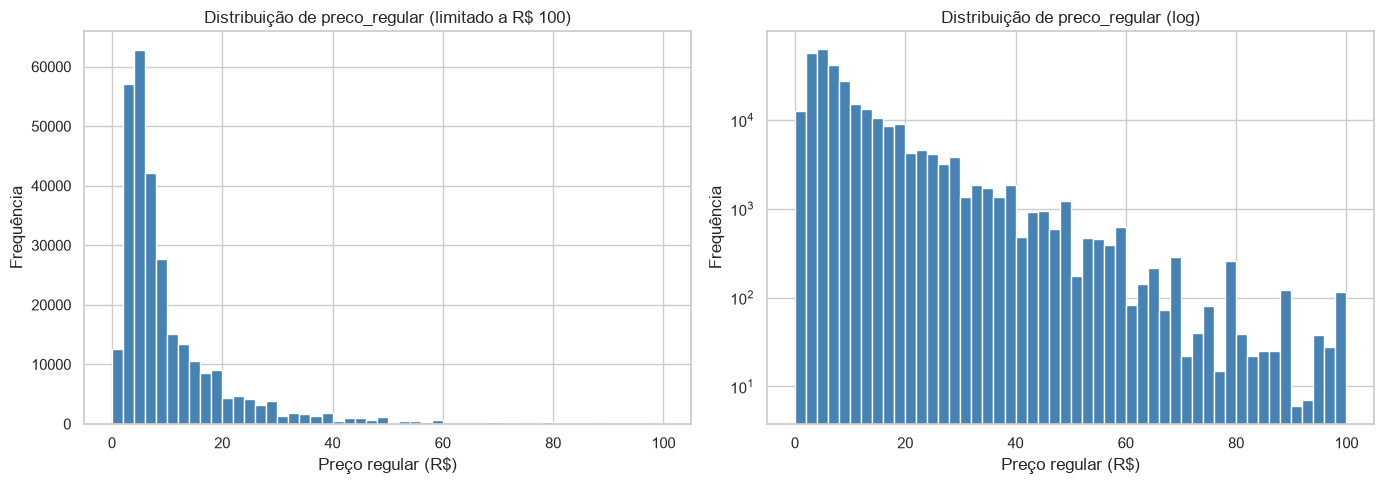

In [9]:
df_clean = df[df["preco_regular"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["preco_regular"].clip(upper=100), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição de preco_regular (limitado a R$ 100)")
axes[0].set_xlabel("Preço regular (R$)")
axes[0].set_ylabel("Frequência")

axes[1].hist(df_clean["preco_regular"].clip(upper=100), bins=50, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Distribuição de preco_regular (log)")
axes[1].set_xlabel("Preço regular (R$)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.savefig("../docs/figuras/distribuicao_preco_regular.png", dpi=150)
plt.show()

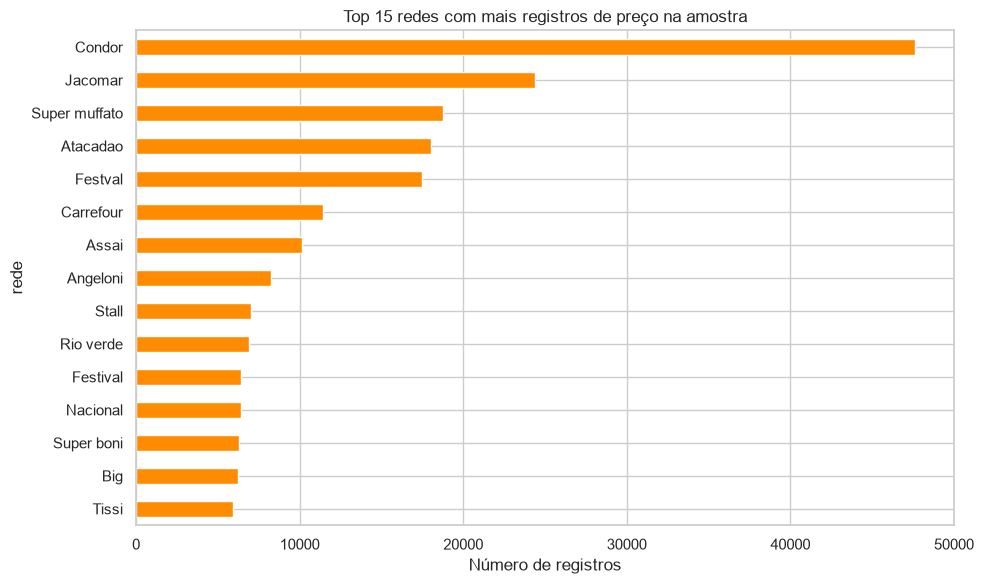

In [10]:
top_redes = df["rede"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_redes.plot(kind="barh", color="darkorange")
plt.title("Top 15 redes com mais registros de preço na amostra")
plt.xlabel("Número de registros")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../docs/figuras/top_redes.png", dpi=150)
plt.show()

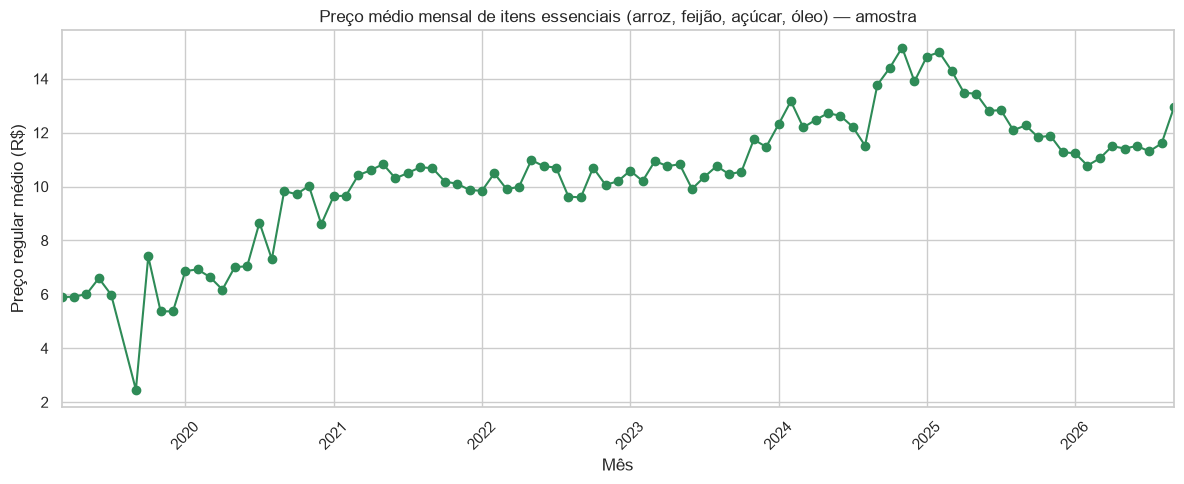

Itens essenciais na amostra: 31,717


In [11]:
basic_items = ["arroz", "feijao", "acucar", "oleo"]
pattern = "|".join(basic_items)
df_basic_items = df_clean[df_clean["descricao"].str.lower().str.contains(pattern, na=False)].copy()
df_basic_items["ano_mes"] = df_basic_items["data_pesquisa"].dt.to_period("M")

monthly_series = df_basic_items.groupby("ano_mes")["preco_regular"].mean()

plt.figure(figsize=(12, 5))
monthly_series.plot(marker="o", color="seagreen")
plt.title("Preço médio mensal de itens essenciais (arroz, feijão, açúcar, óleo) — amostra")
plt.xlabel("Mês")
plt.ylabel("Preço regular médio (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../docs/figuras/serie_temporal_itens_essenciais.png", dpi=150)
plt.show()

print(f"Itens essenciais na amostra: {len(df_basic_items):,}")

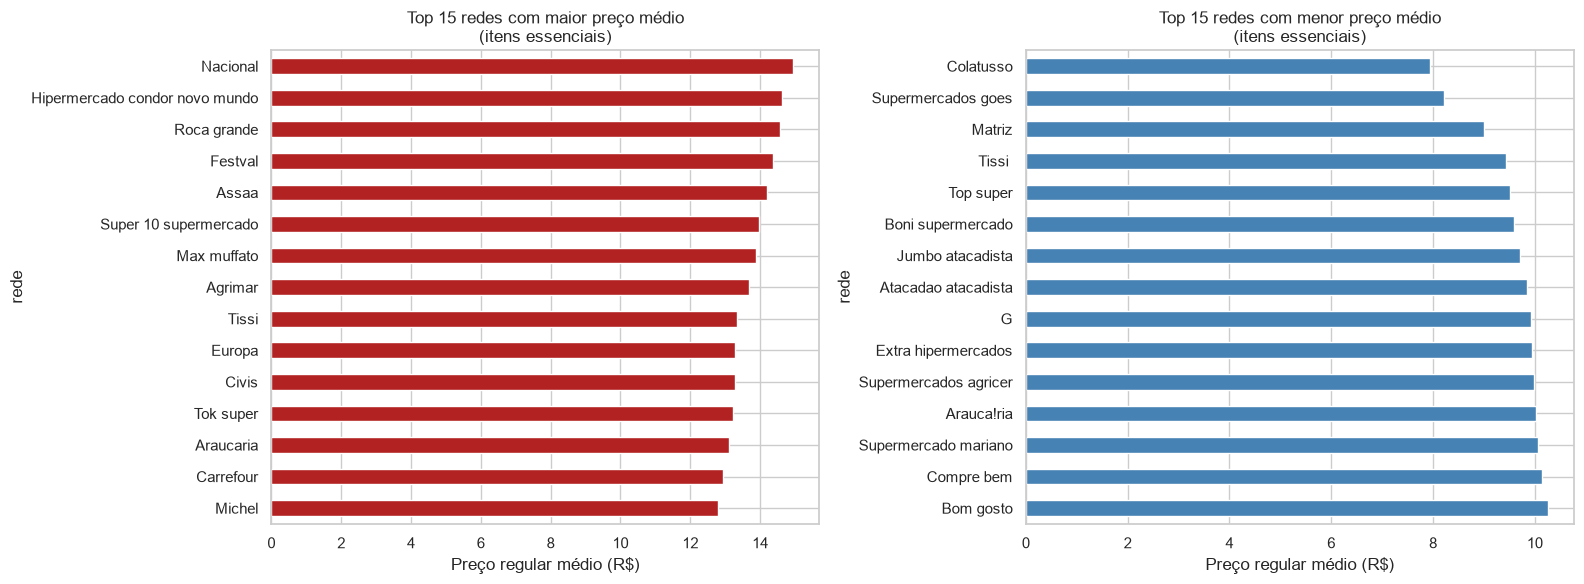

In [12]:
network_counts = df_basic_items["rede"].value_counts()
relevant_networks = network_counts[network_counts >= 30].index

avg_price_by_network = (
    df_basic_items[df_basic_items["rede"].isin(relevant_networks)]
    .groupby("rede")["preco_regular"]
    .mean()
    .sort_values(ascending=False)
)

top_highest = avg_price_by_network.head(15)
top_lowest = avg_price_by_network.tail(15).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_highest.plot(kind="barh", color="firebrick", ax=axes[0])
axes[0].set_title("Top 15 redes com maior preço médio\n(itens essenciais)")
axes[0].set_xlabel("Preço regular médio (R$)")
axes[0].invert_yaxis()

top_lowest.plot(kind="barh", color="steelblue", ax=axes[1])
axes[1].set_title("Top 15 redes com menor preço médio\n(itens essenciais)")
axes[1].set_xlabel("Preço regular médio (R$)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../docs/figuras/preco_essenciais_por_rede.png", dpi=150)
plt.show()